In [5]:
import  numpy as np
import pandas as pd

In [6]:
books = pd.read_csv('../artifacts/Books.csv')

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16412\2474113956.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../artifacts/Books.csv')


In [7]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [8]:
users = pd.read_csv('../artifacts/Users.csv')


In [9]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [10]:
ratings = pd.read_csv('../artifacts/Ratings.csv')


In [11]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [12]:
books.shape

(271360, 8)

In [13]:
users.shape

(278858, 3)

In [14]:
ratings.shape

(1149780, 3)

check missing values

In [15]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [16]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [17]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

check duplicated values

In [18]:
books.duplicated().sum()

np.int64(0)

In [19]:
ratings.duplicated().sum()

np.int64(0)

In [20]:
users.duplicated().sum()

np.int64(0)

popularity based recommender system

In [21]:
books_with_ratings = ratings.merge(books,on="ISBN")

In [22]:
books_with_ratings.shape

(1031136, 10)

In [23]:
books_with_ratings.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


no of books with same name and different isbn

In [24]:
books_with_ratings.groupby('Book-Title').count()

,User-ID,ISBN,Book-Rating,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
Book-Title,,,,,,,,,
"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)",4,4,4,4,4,4,4,4,4
Always Have Popsicles,1,1,1,1,1,1,1,1,1
Apple Magic (The Collector's series),1,1,1,1,1,1,1,1,1
"Ask Lily (Young Women of Faith: Lily Series, Book 5)",1,1,1,1,1,1,1,1,1
Beyond IBM: Leadership Marketing and Finance for the 1990s,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...
Ã?Â?lpiraten.,2,2,2,2,2,2,2,2,2
Ã?Â?rger mit Produkt X. Roman.,4,4,4,4,4,4,4,4,4
Ã?Â?sterlich leben.,1,1,1,1,1,1,1,1,1


In [25]:
books_with_ratings.groupby('Book-Title').count()["Book-Rating"]

Book-Title
 A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)    4
 Always Have Popsicles                                                                                        1
 Apple Magic (The Collector's series)                                                                         1
 Ask Lily (Young Women of Faith: Lily Series, Book 5)                                                         1
 Beyond IBM: Leadership Marketing and Finance for the 1990s                                                   1
                                                                                                             ..
Ã?Â?lpiraten.                                                                                                 2
Ã?Â?rger mit Produkt X. Roman.                                                                                4
Ã?Â?sterlich leben.                                                                          

In [26]:
book_rating_df =books_with_ratings.groupby('Book-Title').count()["Book-Rating"].reset_index()

In [27]:
avg_rating_df = books_with_ratings.groupby('Book-Title').mean('Book-Rating').reset_index()

In [28]:
book_rating_df.rename(columns={'Book-Title':'title','Book-Rating':'num_ratings'},inplace=True)
avg_rating_df.rename(columns={'Book-Title':'title','Book-Rating':'avg_rating'},inplace=True)


In [29]:
book_rating_df.head()

,title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1


In [30]:
avg_rating_df.head()

,title,User-ID,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,51807.25,2.25
1,Always Have Popsicles,172742.00,0.00
2,Apple Magic (The Collector's series),198711.00,0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",269557.00,8.00
4,Beyond IBM: Leadership Marketing and Finance ...,11601.00,0.00


In [31]:
avg_rating_df.drop('User-ID',axis=1,inplace=True)

In [32]:
avg_rating_df.head()

,title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.25
1,Always Have Popsicles,0.00
2,Apple Magic (The Collector's series),0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.00
4,Beyond IBM: Leadership Marketing and Finance ...,0.00


In [33]:
pop_df = book_rating_df.merge(avg_rating_df,on='title')

In [34]:
pop_df.head()

,title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.25
1,Always Have Popsicles,1,0.00
2,Apple Magic (The Collector's series),1,0.00
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.00
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.00


In [35]:
# pop_df1 = pop_df[pop_df['ratings']>=250].sort_values('avg_rating',ascending=False).head(50)
pop_df1 = pop_df.sort_values('avg_rating',ascending=False)


In [36]:
pop_df1

,title,num_ratings,avg_rating
219357,Timelock: How Life Got So Hectic and What You ...,1,10.0
219356,Timelines of World History,1,10.0
20452,Bathroom Game Book,1,10.0
151518,"Rookie Princess (Silhouette Desire, No 483)",1,10.0
151505,Roof World,2,10.0
...,...,...,...
240994,name the baby.,1,0.0
240995,namedropping.,4,0.0
240996,net future,1,0.0
90,'Twas the Night Before Christmas,1,0.0


In [37]:
pop_df2 = books[['Book-Title','Book-Author','Image-URL-M']]

In [38]:
pop_df2.head()

,Book-Title,Book-Author,Image-URL-M
0,Classical Mythology,Mark P. O. Morford,http://images.amazon.com/images/P/0195153448.0...
1,Clara Callan,Richard Bruce Wright,http://images.amazon.com/images/P/0002005018.0...
2,Decision in Normandy,Carlo D'Este,http://images.amazon.com/images/P/0060973129.0...
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,http://images.amazon.com/images/P/0374157065.0...
4,The Mummies of Urumchi,E. J. W. Barber,http://images.amazon.com/images/P/0393045218.0...


In [39]:
pop_df2.rename(columns={'Book-Title':'title',"Book-Author":'author','Image-URL-M':'imgurl'},inplace=True)

C:\Users\lenovo\AppData\Local\Temp\ipykernel_16412\3694021094.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_df2.rename(columns={'Book-Title':'title',"Book-Author":'author','Image-URL-M':'imgurl'},inplace=True)


In [40]:
pop_df2.head()

,title,author,imgurl
0,Classical Mythology,Mark P. O. Morford,http://images.amazon.com/images/P/0195153448.0...
1,Clara Callan,Richard Bruce Wright,http://images.amazon.com/images/P/0002005018.0...
2,Decision in Normandy,Carlo D'Este,http://images.amazon.com/images/P/0060973129.0...
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,http://images.amazon.com/images/P/0374157065.0...
4,The Mummies of Urumchi,E. J. W. Barber,http://images.amazon.com/images/P/0393045218.0...


In [41]:
pop_50_df = pop_df2.merge(pop_df1,on='title')

In [42]:
pop_50_df

,title,author,imgurl,num_ratings,avg_rating
0,Classical Mythology,Mark P. O. Morford,http://images.amazon.com/images/P/0195153448.0...,2,3.500000
1,Clara Callan,Richard Bruce Wright,http://images.amazon.com/images/P/0002005018.0...,14,4.928571
2,Decision in Normandy,Carlo D'Este,http://images.amazon.com/images/P/0060973129.0...,3,5.000000
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,http://images.amazon.com/images/P/0374157065.0...,11,4.272727
4,The Mummies of Urumchi,E. J. W. Barber,http://images.amazon.com/images/P/0393045218.0...,1,0.000000
...,...,...,...,...,...
270291,There's a Bat in Bunk Five,Paula Danziger,http://images.amazon.com/images/P/0440400988.0...,15,3.800000
270292,From One to One Hundred,Teri Sloat,http://images.amazon.com/images/P/0525447644.0...,1,4.000000
270293,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,http://images.amazon.com/images/P/006008667X.0...,1,0.000000
270294,Republic (World's Classics),Plato,http://images.amazon.com/images/P/0192126040.0...,1,0.000000


In [43]:
pop_50_df = pop_50_df[pop_50_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50).reset_index(drop=True)


In [44]:
#31:42

### popular 50 book with highest average rating and get more than 250 ratings

In [45]:
pop_50_df

,title,author,imgurl,num_ratings,avg_rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0786222743.0...,428,5.852804
1,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136369.0...,428,5.852804
2,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
4,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139600.0...,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/043936213X.0...,278,5.737410
6,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
7,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/043936213X.0...,278,5.737410
8,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/043920352X.0...,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441


Collaborative Filtering Based Recommandation System

In [46]:
books_with_ratings

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [47]:
user_200 = books_with_ratings.groupby('User-ID').count()['Book-Rating'] > 200

In [48]:
user_200[user_200]

User-ID
254       True
2276      True
2766      True
2977      True
3363      True
          ... 
274308    True
275970    True
277427    True
277639    True
278418    True
Name: Book-Rating, Length: 811, dtype: bool

In [49]:
user_rate_great200 = user_200[user_200].index

### Users who gave rating more than 200 book we can say Professional standard:
Due to their reputation, a positive review can significantly influence a book's sales. 

In [50]:
user_rate_great200

Index([   254,   2276,   2766,   2977,   3363,   4017,   4385,   6251,   6323,
         6543,
       ...
       271705, 273979, 274004, 274061, 274301, 274308, 275970, 277427, 277639,
       278418],
      dtype='int64', name='User-ID', length=811)

In [51]:
filtered_rating = books_with_ratings[books_with_ratings['User-ID'].isin(user_rate_great200)]

### Books which get review from those Reviewers

In [52]:
filtered_rating.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1151,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...,http://images.amazon.com/images/P/0026217457.0...
1152,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...,http://images.amazon.com/images/P/003008685X.0...
1153,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...,http://images.amazon.com/images/P/0030615321.0...
1154,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...,http://images.amazon.com/images/P/0060002050.0...


In [53]:
book_rate50 = filtered_rating.groupby('Book-Title').count()['Book-Rating'] >=50

### Books which get more than 50 reviews from those Reviewers

In [54]:
book_rate50

Book-Title
 A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)    False
 Always Have Popsicles                                                                                        False
 Apple Magic (The Collector's series)                                                                         False
 Beyond IBM: Leadership Marketing and Finance for the 1990s                                                   False
 Clifford Visita El Hospital (Clifford El Gran Perro Colorado)                                                False
                                                                                                              ...  
Ã?Â?ber das Fernsehen.                                                                                        False
Ã?Â?ber die Pflicht zum Ungehorsam gegen den Staat.                                                           False
Ã?Â?lpiraten.                                                

In [55]:
famous_book = book_rate50[book_rate50].index

In [56]:
famous_book

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Day Late and a Dollar Short', 'A Fine Balance',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='object', name='Book-Title', length=706)

In [57]:
final_rating = filtered_rating[filtered_rating['Book-Title'].isin(famous_book)]

In [58]:
final_rating.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1150,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...,http://images.amazon.com/images/P/002542730X.0...
1163,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...,http://images.amazon.com/images/P/0060930535.0...
1165,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...,http://images.amazon.com/images/P/0060934417.0...
1168,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...,http://images.amazon.com/images/P/0061009059.0...
1174,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...,http://images.amazon.com/images/P/006440188X.0...


In [59]:
piv_tab = final_rating.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

### pivot for book and user related by ratings

In [60]:
piv_tab

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1st to Die: A Novel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2nd Chance,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN
4 Blondes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A Bend in the Road,0.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,0.0,...,NaN,9.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
You Belong To Me,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [61]:
piv_tab.fillna(0,inplace=True)

In [62]:
piv_tab

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### each book row create a vector contains ratings from various users

we do dot product of each row vector with rest of the rows vector to find cosine similarity with each row vector
that represents similarity of each book with other book

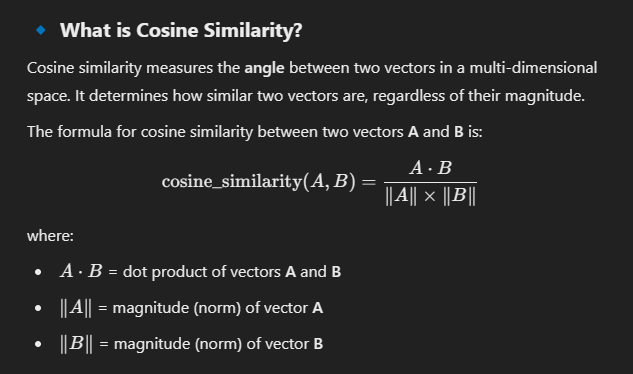

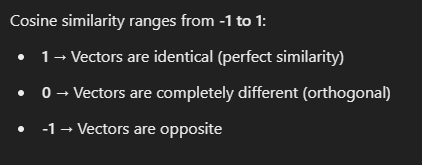

similarity between A and B

In [63]:
A =[5, 0, 3, 0] 
B =[4, 0, 4, 1]

cos_theta = (5*4+0*0+3*4+0*1)/(((5**2+0**2+3**2+0**2)**0.5)*((4**2+0**2+4**2+1**2)**0.5))

In [64]:
cos_theta # similarity between A and B

0.9553302944424514

In [65]:
from sklearn.metrics.pairwise import cosine_similarity

In [66]:
similarity_scores = cosine_similarity(piv_tab)

In [67]:
similarity_scores.shape

(706, 706)

similarity values of first book with others book
first value is 1 because similarity between same book

In [68]:
similarity_scores[0]

array([1.        , 0.10255025, 0.01220856, 0.        , 0.05367224,
       0.02774901, 0.08216491, 0.13732869, 0.03261686, 0.03667591,
       0.02322418, 0.06766487, 0.02083978, 0.09673735, 0.13388865,
       0.08303112, 0.11153543, 0.05100411, 0.02517784, 0.11706383,
       0.        , 0.14333793, 0.07847534, 0.06150451, 0.08723968,
       0.        , 0.07009814, 0.13658681, 0.07600328, 0.12167134,
       0.00768046, 0.01473221, 0.        , 0.07965814, 0.04522617,
       0.01556271, 0.09495938, 0.0182307 , 0.02610465, 0.07984012,
       0.11679969, 0.0569124 , 0.08354155, 0.08471898, 0.08785938,
       0.05491435, 0.0548505 , 0.27026514, 0.09779123, 0.06016046,
       0.08958835, 0.06748675, 0.        , 0.04468098, 0.01920872,
       0.        , 0.05629067, 0.00557964, 0.07877059, 0.05219479,
       0.18908177, 0.        , 0.01240656, 0.02984572, 0.04279502,
       0.12680125, 0.16566735, 0.        , 0.13357242, 0.06615478,
       0.        , 0.        , 0.        , 0.10968075, 0.02806

test for "2nd book"

In [69]:
index = np.where(piv_tab.index=='2nd Chance')[0][0]

In [70]:
index

np.int64(2)

In [73]:
enumerate(similarity_scores[index])

In [74]:
list(enumerate(similarity_scores[index]))

[(0, np.float64(0.012208555646509366)),
 (1, np.float64(0.236457295254443)),
 (2, np.float64(1.0)),
 (3, np.float64(0.0)),
 (4, np.float64(0.06909024214591328)),
 (5, np.float64(0.10559126382470128)),
 (6, np.float64(0.0)),
 (7, np.float64(0.10774375110550646)),
 (8, np.float64(0.0670218487291342)),
 (9, np.float64(0.0416819540485443)),
 (10, np.float64(0.04772156476776279)),
 (11, np.float64(0.0)),
 (12, np.float64(0.047580047424453376)),
 (13, np.float64(0.044455151509031496)),
 (14, np.float64(0.052007058137221944)),
 (15, np.float64(0.09877662230505671)),
 (16, np.float64(0.06505524505788216)),
 (17, np.float64(0.16998812090738538)),
 (18, np.float64(0.11381916242700778)),
 (19, np.float64(0.11713887938926706)),
 (20, np.float64(0.034240966437880764)),
 (21, np.float64(0.0878014420489393)),
 (22, np.float64(0.1973490309636965)),
 (23, np.float64(0.0)),
 (24, np.float64(0.1029666684450606)),
 (25, np.float64(0.0)),
 (26, np.float64(0.058626484557583125)),
 (27, np.float64(0.03167737

In [75]:
sorted(list(enumerate(similarity_scores[index])),key=lambda x : x[1], reverse=True)

[(2, np.float64(1.0)),
 (203, np.float64(0.3918276378683357)),
 (577, np.float64(0.34991368995007677)),
 (666, np.float64(0.30619341327105154)),
 (575, np.float64(0.2946892769829446)),
 (198, np.float64(0.2744597369070355)),
 (338, np.float64(0.26840230908242607)),
 (96, np.float64(0.26814324064048733)),
 (486, np.float64(0.25932139662678516)),
 (166, np.float64(0.2524098979487631)),
 (368, np.float64(0.2508772113214677)),
 (382, np.float64(0.24923306067547385)),
 (81, np.float64(0.24169010979761996)),
 (130, np.float64(0.2380506201999118)),
 (1, np.float64(0.236457295254443)),
 (582, np.float64(0.2331269920232123)),
 (427, np.float64(0.22914085583719118)),
 (193, np.float64(0.22709354851686991)),
 (495, np.float64(0.22646115140179204)),
 (80, np.float64(0.2261405280701767)),
 (483, np.float64(0.2245044128101898)),
 (205, np.float64(0.22027645398763274)),
 (172, np.float64(0.21765288149629525)),
 (352, np.float64(0.21708609119306566)),
 (518, np.float64(0.21433446878135592)),
 (659, np

take only 6 simlar books

In [71]:
similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x : x[1], reverse=True)[0:6]

In [72]:
similar_items

[(2, np.float64(1.0)),
 (203, np.float64(0.3918276378683357)),
 (577, np.float64(0.34991368995007677)),
 (666, np.float64(0.30619341327105154)),
 (575, np.float64(0.2946892769829446)),
 (198, np.float64(0.2744597369070355))]

In [76]:
for i in similar_items:
    print(piv_tab.index[i[0]])
    

2nd Chance
Four Blind Mice
The Next Accident
Violets Are Blue
The Murder Book
Flesh and Blood


In [77]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [ ]:
temp_df = books[books['Book-Title'] == piv_tab.index[i[0]]] # i=5

In [80]:
temp_df

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
1871,0679459626,Flesh and Blood,Jonathan Kellerman,2001,Random House,http://images.amazon.com/images/P/0679459626.0...,http://images.amazon.com/images/P/0679459626.0...,http://images.amazon.com/images/P/0679459626.0...
4265,034541389X,Flesh and Blood,Jonathan Kellerman,2002,Ballantine Books,http://images.amazon.com/images/P/034541389X.0...,http://images.amazon.com/images/P/034541389X.0...,http://images.amazon.com/images/P/034541389X.0...
38722,1860491308,Flesh and Blood,Michele Roberts,1995,Time Warner Books UK,http://images.amazon.com/images/P/1860491308.0...,http://images.amazon.com/images/P/1860491308.0...,http://images.amazon.com/images/P/1860491308.0...
47829,0312953186,Flesh and Blood,James Neal Harvey,1996,St Martins Pr (Mm),http://images.amazon.com/images/P/0312953186.0...,http://images.amazon.com/images/P/0312953186.0...,http://images.amazon.com/images/P/0312953186.0...
85613,0881845337,Flesh and Blood,Francois Mauriac,1989,Carroll &amp; Graf Publishers,http://images.amazon.com/images/P/0881845337.0...,http://images.amazon.com/images/P/0881845337.0...,http://images.amazon.com/images/P/0881845337.0...
139211,0425131785,Flesh and Blood,Thomas H. Cook,1992,Berkley Pub Group,http://images.amazon.com/images/P/0425131785.0...,http://images.amazon.com/images/P/0425131785.0...,http://images.amazon.com/images/P/0425131785.0...
160996,0374181136,Flesh and Blood,Michael Cunningham,1995,Farrar Straus &amp; Giroux,http://images.amazon.com/images/P/0374181136.0...,http://images.amazon.com/images/P/0374181136.0...,http://images.amazon.com/images/P/0374181136.0...
195659,0786004517,Flesh and Blood,Patricia Springer,1997,Pinnacle Books,http://images.amazon.com/images/P/0786004517.0...,http://images.amazon.com/images/P/0786004517.0...,http://images.amazon.com/images/P/0786004517.0...
200032,185381752X,Flesh and Blood,Michele Roberts,1994,Time Warner Books UK,http://images.amazon.com/images/P/185381752X.0...,http://images.amazon.com/images/P/185381752X.0...,http://images.amazon.com/images/P/185381752X.0...
215352,0888783876,Flesh and Blood,Michael Crummey,2001,Porcepic Books,http://images.amazon.com/images/P/0888783876.0...,http://images.amazon.com/images/P/0888783876.0...,http://images.amazon.com/images/P/0888783876.0...


In [84]:
temp_df.drop_duplicates('Book-Title')['Book-Title'].values

array(['Flesh and Blood'], dtype=object)

In [73]:
#to find the index position of book by name
def recommend(book_name):
    #index fetch
    index = np.where(piv_tab.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x : x[1], reverse=True)[0:6]

    data =[]
    for i in similar_items:
        item =[]
        # print(f"Book Title: {piv_tab.index[i[0]]}, Similarity Score: {i[1]}")
        temp_df = books[books['Book-Title'] == piv_tab.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))

        data.append(item)

    return data




In [74]:
recommend('The Da Vinci Code')

[['The Da Vinci Code',
  'Dan Brown',
  'http://images.amazon.com/images/P/0385504209.01.MZZZZZZZ.jpg'],
 ['Angels &amp; Demons',
  'Dan Brown',
  'http://images.amazon.com/images/P/0671027360.01.MZZZZZZZ.jpg'],
 ['Touching Evil',
  'Kay Hooper',
  'http://images.amazon.com/images/P/0553583441.01.MZZZZZZZ.jpg'],
 ['Saving Faith',
  'David Baldacci',
  'http://images.amazon.com/images/P/0446608890.01.MZZZZZZZ.jpg'],
 ["The Sweet Potato Queens' Book of Love",
  'JILL CONNER BROWNE',
  'http://images.amazon.com/images/P/0609804138.01.MZZZZZZZ.jpg'],
 ['Middlesex: A Novel',
  'Jeffrey Eugenides',
  'http://images.amazon.com/images/P/0312422156.01.MZZZZZZZ.jpg']]

In [69]:
np.where(piv_tab.index=='2nd Chance')


(array([2]),)

In [70]:
np.where(piv_tab.index=='2nd Chance')[0]

array([2])

In [ ]:
np.where(piv_tab.index=='2nd Chance')[0][0]

np.int64(2)

In [ ]:
sorted(list(enumerate(similarity_scores[0])),key=lambda x : x[1], reverse=True)[1:6]

[(47, np.float64(0.2702651417103732)),
 (545, np.float64(0.2639619371123497)),
 (82, np.float64(0.23669374347400993)),
 (634, np.float64(0.23299389358170394)),
 (551, np.float64(0.2262639743141286))]

In [ ]:
pop_50_df['imgurl']

0     http://images.amazon.com/images/P/0786222743.0...
1     http://images.amazon.com/images/P/0439136369.0...
2     http://images.amazon.com/images/P/0439136350.0...
3     http://images.amazon.com/images/P/0439139597.0...
4     http://images.amazon.com/images/P/0439139600.0...
5     http://images.amazon.com/images/P/043936213X.0...
6     http://images.amazon.com/images/P/0590353403.0...
7     http://images.amazon.com/images/P/043936213X.0...
8     http://images.amazon.com/images/P/043920352X.0...
9     http://images.amazon.com/images/P/043935806X.0...
10    http://images.amazon.com/images/P/0439567610.0...
11    http://images.amazon.com/images/P/043935806X.0...
12    http://images.amazon.com/images/P/0439358078.0...
13    http://images.amazon.com/images/P/0439420105.0...
14    http://images.amazon.com/images/P/0439064872.0...
15    http://images.amazon.com/images/P/0439064864.0...
16    http://images.amazon.com/images/P/0345339681.0...
17    http://images.amazon.com/images/P/06183462

In [75]:
import pickle

In [ ]:
pickle.dump(pop_50_df,open("../model/popular.pkl",'wb'))

In [ ]:
# 1;19:43

In [76]:
pickle.dump(piv_tab,open('../model/pt.pkl','wb'))
pickle.dump(books,open('../model/books.pkl','wb'))
pickle.dump(similarity_scores,open('../model/similarty_scores.pkl','wb'))
